In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
plt.style.use("../../plots.mplstyle")

C:\Users\codin\AppData\Local\Temp\ipykernel_2368\2516428626.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


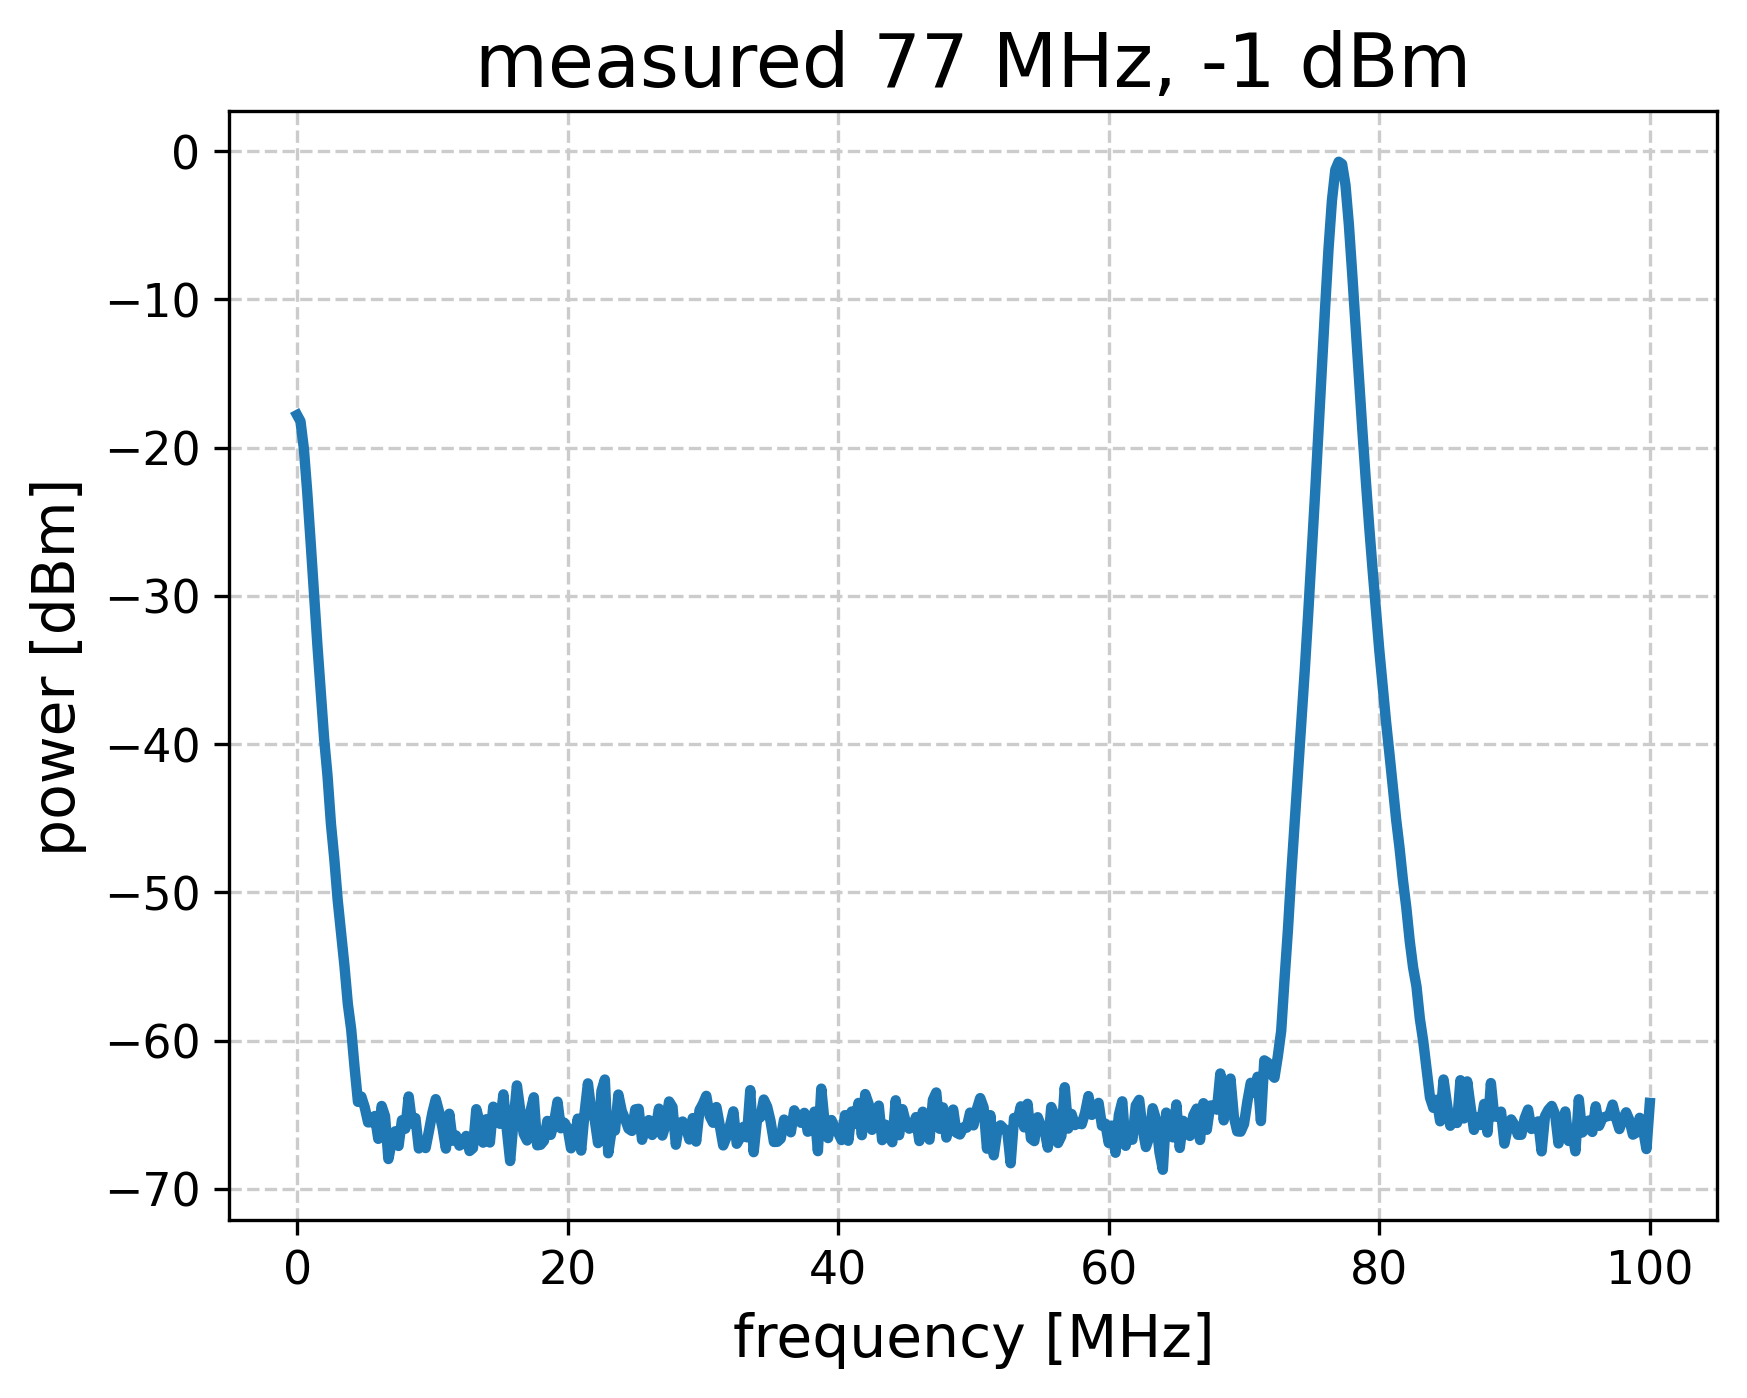

In [152]:
save_dir = Path("./captures")

filename = "output_77_mhz_neg_1_dbm.csv"
filepath = save_dir / filename

loaded = np.loadtxt(filepath, delimiter=",", skiprows=1)

freq = loaded[:, 0]
dbm = loaded[:, 1]

fig, ax = plt.subplots(dpi=300)
ax.plot(freq / 1e6, dbm)
ax.set_xlabel("frequency [MHz]")
ax.set_ylabel("power [dBm]")
ax.set_title("measured 77 MHz, -1 dBm")
# ax.set_ylim([-70, -20])
plt.legend()

In [143]:
def local_peaks(x, y, min_height=-np.inf):
    peaks = np.where(
            (y[1:-1] > y[:-2]) &
            (y[1:-1] > y[2:]) &
            (y[1:-1] >= min_height)
        )[0] + 1
    # peaks = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1

    for i in peaks:
        print(f"{x[i] / 1e6:.2f} MHz, {y[i]:.2f} dBm")

    return peaks

def get_data(path):
    loaded = np.loadtxt(path, delimiter=",", skiprows=1)
    freq = loaded[:, 0]
    dbm = loaded[:, 1]
    return freq, dbm

    

In [121]:
len(local_peaks(freq, dbm))

48.05 MHz, -31.40 dBm
50.00 MHz, -30.27 dBm
52.10 MHz, -30.69 dBm
54.05 MHz, -28.39 dBm
56.00 MHz, -27.84 dBm
58.10 MHz, -28.23 dBm
60.05 MHz, -25.69 dBm
62.00 MHz, -24.66 dBm
63.95 MHz, -24.76 dBm
66.05 MHz, -21.83 dBm
68.00 MHz, -19.99 dBm
69.95 MHz, -19.19 dBm
72.05 MHz, -14.90 dBm
74.00 MHz, -10.28 dBm
75.95 MHz, -2.07 dBm
77.00 MHz, 3.37 dBm
78.05 MHz, -0.78 dBm
80.00 MHz, -10.16 dBm
81.95 MHz, -15.96 dBm
84.05 MHz, -17.69 dBm
86.00 MHz, -19.64 dBm
87.95 MHz, -22.75 dBm
90.05 MHz, -23.04 dBm
92.00 MHz, -24.01 dBm
93.95 MHz, -26.55 dBm
96.05 MHz, -26.35 dBm
98.00 MHz, -26.98 dBm
99.95 MHz, -29.23 dBm
102.05 MHz, -28.82 dBm
104.00 MHz, -29.26 dBm
105.95 MHz, -31.30 dBm


31

In [136]:

def generate_square_wave(period, transitions, cycles=1, dt=0.001):
#        [on1, off1, on2, off2, ...]

    if len(transitions) % 2 != 0:
        raise ValueError("transitions must contain pairs of [on, off] times")

    total_time = cycles * period
    t = np.arange(0, total_time, dt)
    y = np.zeros_like(t)

    for i in range(0, len(transitions), 2):
        on_time = transitions[i]
        off_time = transitions[i + 1]

        if off_time <= on_time:
            raise ValueError("off time must be greater than on time")

        for c in range(cycles):
            start = c * period + on_time
            stop = c * period + off_time
            y[(t >= start) & (t < stop)] = 1
    return t, y


def generate_sine_wave(
    frequency, # in hz
    total_time, # in seconds
    amplitude=1.0,
    phase=0.0,
    dt=0.001
):
    t = np.arange(0, total_time, dt)
    y = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    return t, y



def compute_fft(t, y):
    dt = t[1] - t[0]
    N = len(y)
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=dt)

    Y = np.fft.fftshift(Y)
    f = np.fft.fftshift(f)

    return f, Y / len(y)

def power_to_dbm(power_watts):
    power_watts = np.asarray(power_watts)
    return 10 * np.log10(power_watts / 1e-3)


def compute_fft_dbm(t, y):
    # calib: at 77 MHz, should be 10 dBm, got 7 dBm
    calibration_factor = 2
    f, Y = compute_fft(t, y)
    dbm = power_to_dbm(np.abs(Y)**2 / 50 * calibration_factor)
    return f, dbm

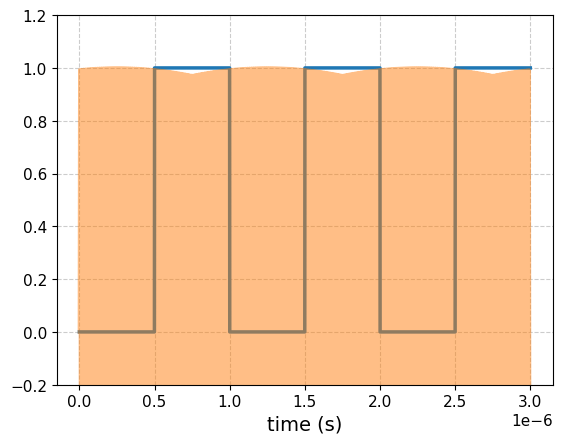

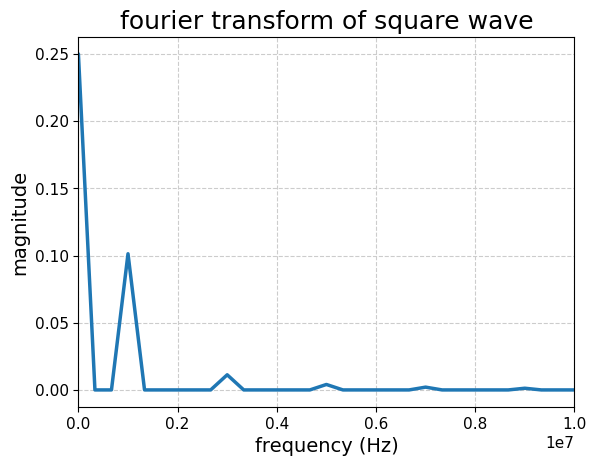

In [140]:
period = 1 / 1e6
transitions = [0.5e-6, 1e-6]

t1, y1 = generate_square_wave(period, transitions, cycles=3, dt=1e-9)
t2, y2 = generate_sine_wave(
    frequency=77e6,      # Hz
    total_time=3e-6,   # seconds
    amplitude=1.0,
    phase=0.0,
    dt=1e-9
)

fig, ax = plt.subplots()
ax.plot(t1, y1)
ax.plot(t2, y2, alpha=0.5)
ax.set_xlabel("time (s)")
ax.set_ylim(-0.2, 1.2)
ax.grid(True)
plt.show()


f1, Y1 = compute_fft(t1, y1)

fig, ax = plt.subplots()
ax.plot(f1, np.abs(Y1)**2)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("magnitude")
ax.set_title("fourier transform of square wave")
ax.grid(True)
ax.set_xlim([0, 10e6])
plt.show()


# mask = np.bitwise_and(f3 > 50e6, f3 < 110e6)
# len(local_peaks(f3[mask], dbm[mask], min_height=-70))



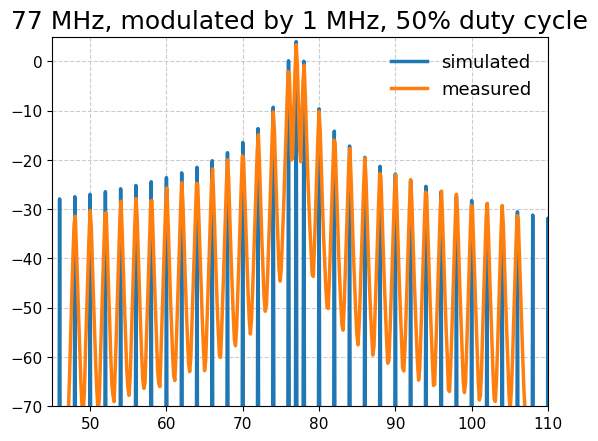

In [153]:
measured_freq, measured_dbm = get_data("./captures/average/10dbm_50_percent_1mhz.csv")

fig, ax = plt.subplots()
f3, dbm = compute_fft_dbm(t2, y2 * y1)

ax.plot(f3 / 1e6, dbm, label="simulated")
ax.plot(measured_freq / 1e6, measured_dbm, label="measured")

ax.set_xlim([45, 110])
ax.set_ylim([-70, 5])
ax.set_title("77 MHz, modulated by 1 MHz, 50% duty cycle")
plt.legend()

C:\Users\codin\AppData\Local\Temp\ipykernel_41492\2883469810.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


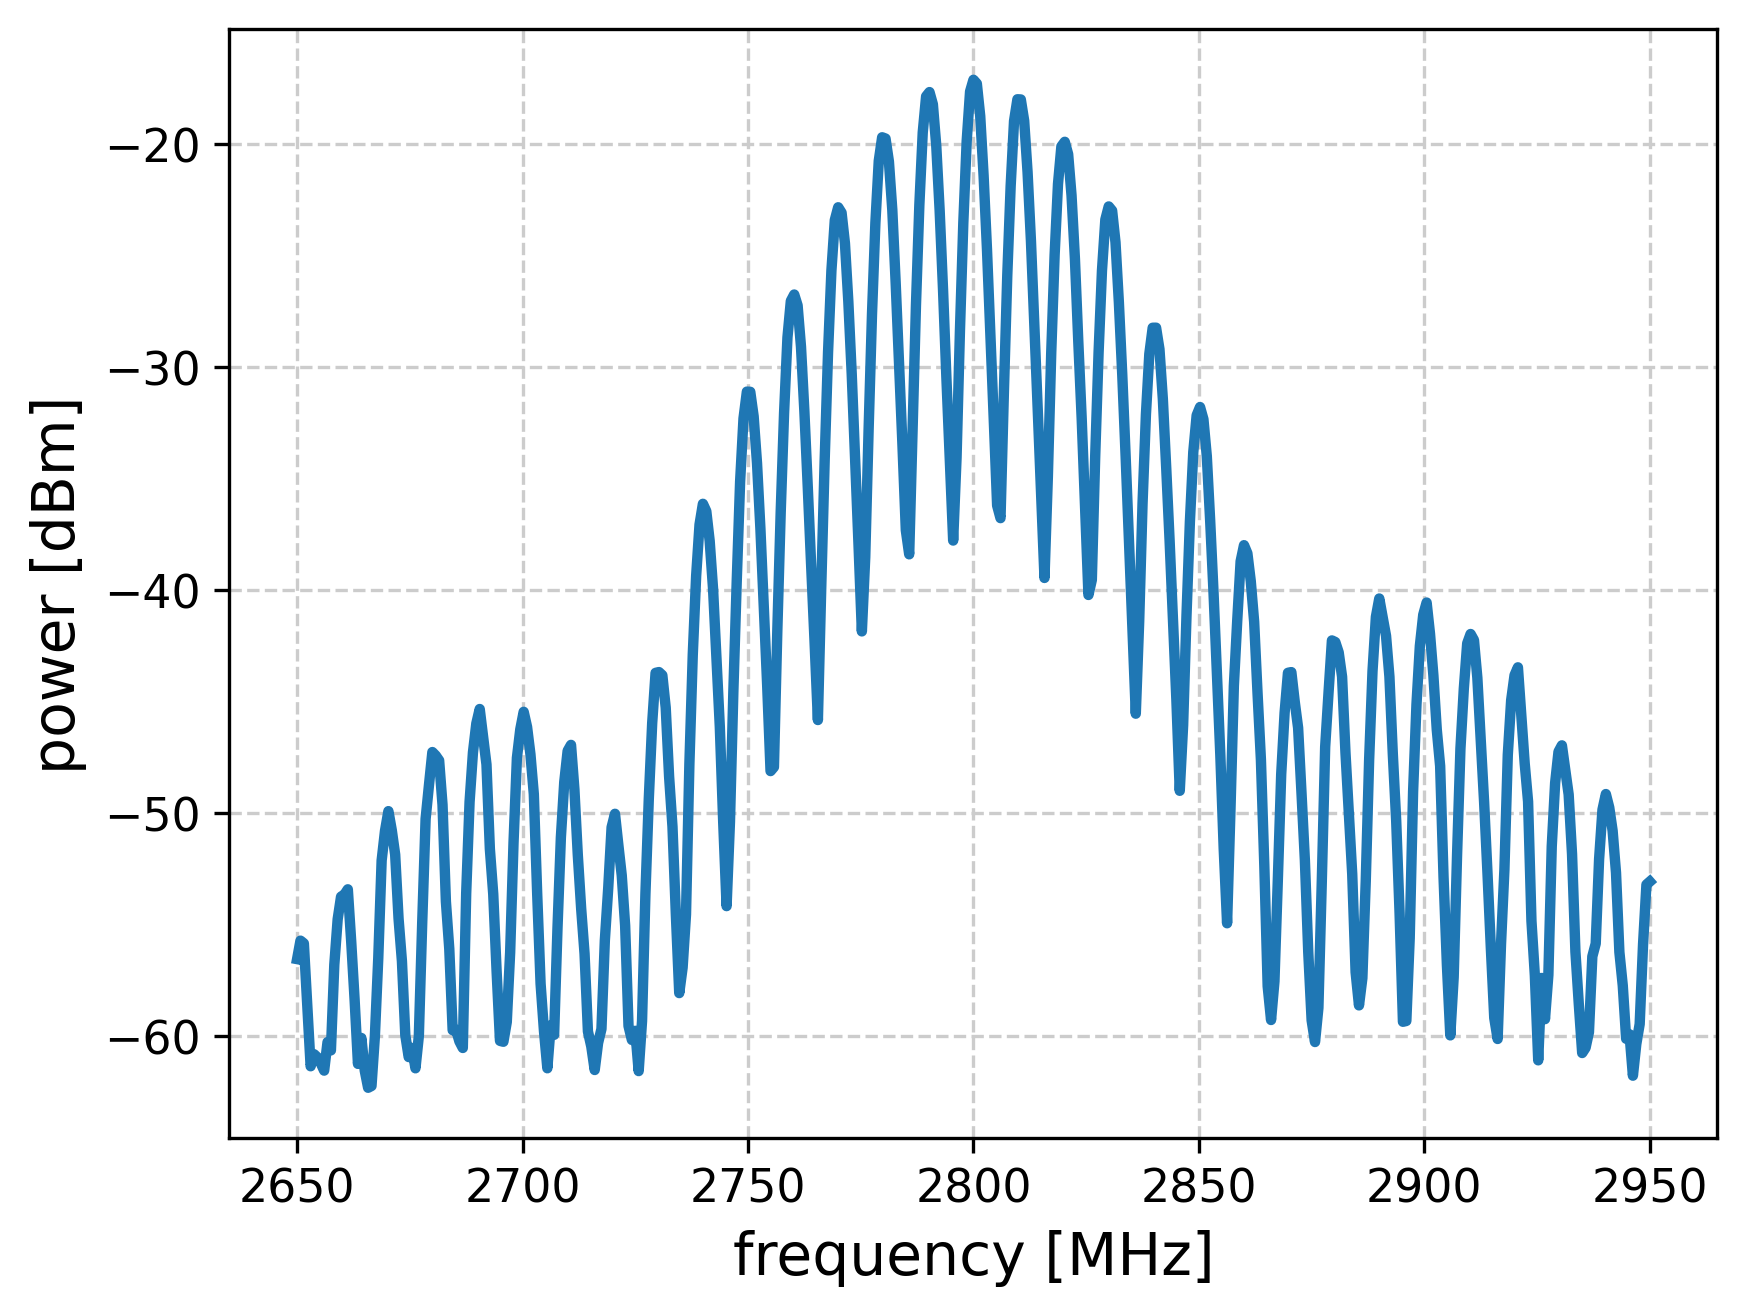

In [ ]:
# -10 dBm output
# at 10 MHz, already unleveled
# but not unleveled at 100 MHz? => no output
# unleveled, but no output at 50 MHz?
save_dir = Path("./microwave")

filename = "10mhz-30-percent.csv"
filepath = save_dir / filename

loaded = np.loadtxt(filepath, delimiter=",", skiprows=1)

freq = loaded[:, 0]
dbm = loaded[:, 1]

fig, ax = plt.subplots(dpi=300)
ax.plot(freq / 1e6, dbm)
ax.set_xlabel("frequency [MHz]")
ax.set_ylabel("power [dBm]")
# ax.set_ylim([-70, -20])
plt.legend()